# Extracting ZIP file

In [14]:
import zipfile

zip_ref = zipfile.ZipFile('H:\\project\\fruits.zip', 'r')

zip_ref.extractall('H:\\project\\fruits')

zip_ref.close()

print("Dataset extracted successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'H:\\project\\fruits.zip'

In [ ]:
from tensorflow import keras

# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory=r'H:\project\fruits_dip\train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (128,128),
    color_mode='rgb',
    shuffle=True
)


val_ds = keras.utils.image_dataset_from_directory(
    directory=r'H:\project\fruits_dip\valid',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (128,128),
    color_mode='rgb',
    shuffle=True
)

ModuleNotFoundError: No module named 'tensorflow'

: 

In [ ]:
print(train_ds.class_names)


['apple', 'avocado', 'blueberry', 'capsicum']


: 

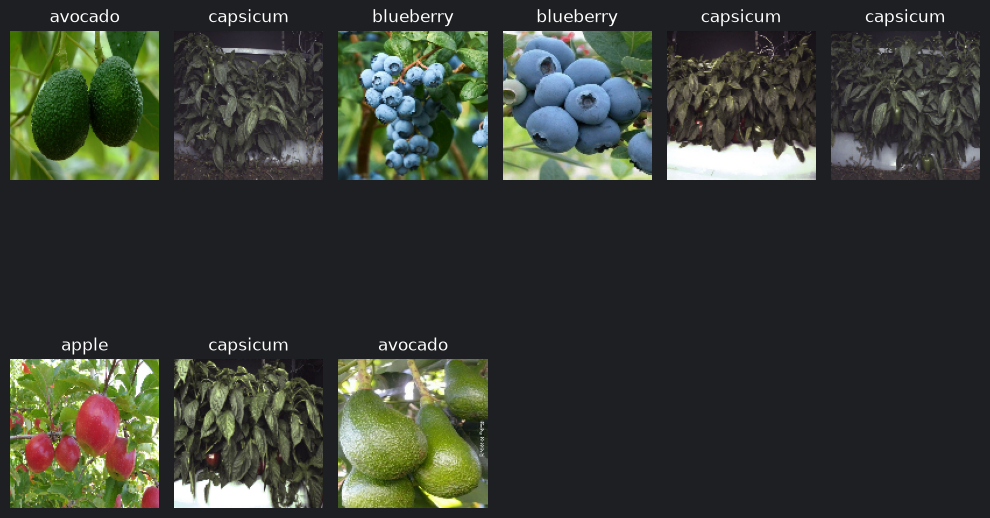

: 

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get class names
class_names = train_ds.class_names

# Extract one batch from the dataset
for images, labels in train_ds.take(1):
    images = images.numpy().astype("uint8")
    labels = labels.numpy()

    # Set up subplot grid
    plt.figure(figsize=(10, 10))

    for i in range(9):  # First 9 images
        ax = plt.subplot(3, 6, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Model Building

In [ ]:
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Input, Dropout

model = Sequential()
model.add(Input(shape=(128,128,3)))
model.add(Conv2D(32, kernel_size=(3, 3),activation='relu',padding="same",))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3),padding='same'))


model.add(Conv2D(64, kernel_size=(3, 3),activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3),padding='same'))


model.add(Conv2D(128, kernel_size=(3, 3),activation='relu',padding="same"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3),padding='same'))


model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))

: 

: 

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 43, 43, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 43, 43, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 15, 15, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       409,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 512,388 (1.95 MB)

 Trainable params: 511,940 (1.95 MB)

 Non-trainable params: 448 (1.75 KB)

: 

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])



NameError: name 'model' is not defined

: 

# Model Training

In [ ]:
epochs=20
history = model.fit(train_ds, epochs=epochs, validation_data=val_ds)

NameError: name 'model' is not defined

: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

: 

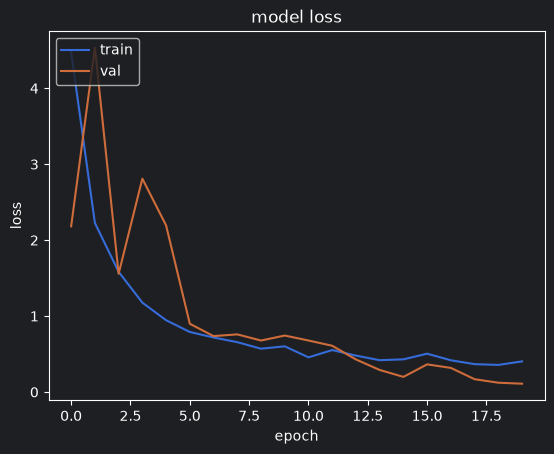

: 

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(val_ds)

print(f"Validation Accuracy: {val_accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4734 - loss: 1.1449
Validation Accuracy: 0.4734


: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get class names
class_names = val_ds.class_names

# Step 1: Collect true and predicted labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)  # get class with highest probability

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


ModuleNotFoundError: No module named 'numpy'

: 

In [ ]:
print(val_ds.class_names)

NameError: name 'val_ds' is not defined

: 

In [ ]:
print("Classification Report:")

print(classification_report(
    y_true,
    y_pred,
    labels=[0,1],
    target_names=class_names
))

Classification Report:


NameError: name 'classification_report' is not defined

: 

In [ ]:
# Step 2: Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:


NameError: name 'classification_report' is not defined

: 

In [ ]:
from sklearn.metrics import confusion_matrix

: 

In [ ]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


: 

In [ ]:
import numpy as np

print("Class Names:", train_ds.class_names)
print("Unique y_true:", np.unique(y_true))
print("Unique y_pred:", np.unique(y_pred))
print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)

Class Names: ['apple', 'avocado', 'blueberry', 'capsicum']
Unique y_true: [0 1 2 3]
Unique y_pred: [0 1 2 3]
y_true shape: (188,)
y_pred shape: (188,)


: 

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# Create empty lists
y_true = []
y_pred = []


# Get prediction from validation dataset
for images, labels in val_ds:

    predictions = model.predict(images)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)


# Convert to numpy array
y_true = np.array(y_true)
y_pred = np.array(y_pred)


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)


# Classification Report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)


# Plot Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

ModuleNotFoundError: No module named 'numpy'

: 

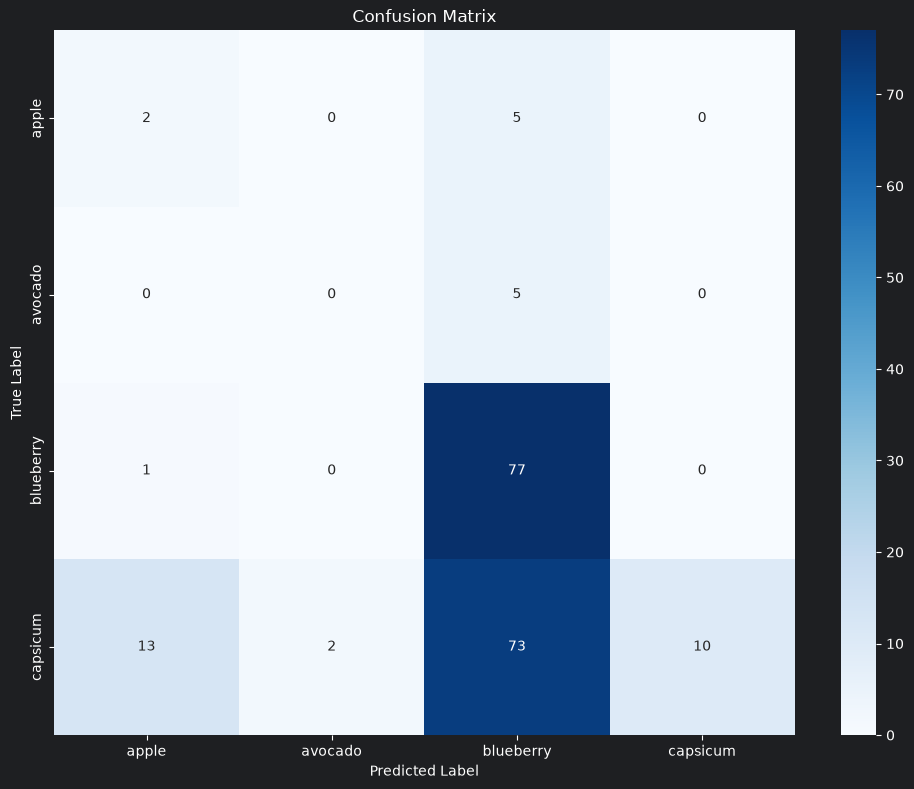

: 

In [ ]:
# Step 3: Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


: 

In [15]:
import gradio as gr
import tensorflow as tf
import numpy as np



# Prediction function
def predict(image):
    # Resize and normalize image
    img = tf.image.resize(image, (128, 128))  # match model input size
    img = tf.expand_dims(img, axis=0)         # add batch dimension


    # Predict
    pred = model.predict(img)
    class_idx = np.argmax(pred[0])
    class_name = class_names[class_idx]
    confidence = float(pred[0][class_idx])

    return {class_name: confidence}

# Gradio interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    title="Fruits Classifier",
    description="Upload a fruit image to identify its category."
)

# Launch the app
interface.launch()


ModuleNotFoundError: No module named 'gradio'

: 